[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opherdonchin/ModelsOfTheMotorSystems/blob/master/In%20class%20exercises/Ex9_Solution.ipynb)

# Lecture 9 In-Class Assignment: Multi-State Models and Spontaneous Recovery - Solution

Smith, Ghazizadeh, and Shadmehr (2006) proposed that short-term motor adaptation is not a single memory. Instead, behavior can reflect the sum of a **fast** process that learns quickly and forgets quickly, and a **slow** process that learns slowly and forgets slowly.

In this exercise you will build the model in stages:

1. Write the generative equations for a one-state model.
2. Show that a one-state model does not produce spontaneous recovery after visible behavior has returned to baseline.
3. Write the generative equations for a two-state model.
4. Add human-level noise and ask whether the qualitative effect is still visible.

We will use degrees as the unit of the perturbation and motor output.

<a id="section1"></a>
## 1. Imports & Setup

**DO NOT EDIT**: imports, plotting defaults, model parameters from Smith et al. (2006), and a small `check` helper.

The key parameters are:

- one-state model: $A = 0.99$, $B = 0.013$
- two-state model: $A_f = 0.92$, $B_f = 0.03$, $A_s = 0.996$, $B_s = 0.004$

Here $A$ terms are retention/forgetting terms and $B$ terms are error sensitivity/learning terms.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True


def check(name, got, expected, atol=1e-8):
    """Non-crashing test: print whether `got` is close to `expected`."""
    if np.allclose(got, expected, atol=atol):
        print(f"PASS: {name}")
    else:
        print(f"CHECK: {name}")
        print(f"  got      {got}")
        print(f"  expected {expected}")


# ---- Smith et al. (2006) parameters ----
A_single = 0.99
B_single = 0.013

A_fast = 0.92
B_fast = 0.03
A_slow = 0.996
B_slow = 0.004

# ---- In-class paradigm ----
baseline_trials = 20
learning_trials = 120
max_extinction_trials = 120
clamp_trials = 80

adaptation_field = 30.0       # degrees
extinction_field = -30.0      # degrees
baseline_tolerance = 0.25     # stop extinction when behavior is this close to zero

# Roughly human-sized trial-to-trial reach-angle variability.
human_noise_sd = 2.0          # degrees

<a id="section2"></a>
## 2. The Error Signal

The learner changes its state from the error on the current trial:

$$ e(n) = f(n) - x(n) $$

where $f(n)$ is the imposed perturbation and $x(n)$ is the learner's current motor output. If the field is `30` degrees and the learner currently produces `20` degrees of compensation, the remaining error is `10` degrees.

In [2]:
def compute_error(environment, motor_output):
    # STUDENT CODE HERE
    return environment - motor_output


check("error when output is zero", compute_error(30.0, 0.0), 30.0)
check("error after partial compensation", compute_error(30.0, 20.0), 10.0)
check("opposite field error", compute_error(-30.0, 5.0), -35.0)

PASS: error when output is zero
PASS: error after partial compensation
PASS: opposite field error


<a id="section3"></a>
## 3. Part A - One-State Model

The one-state model has one adaptive memory:

$$ x(n+1) = A x(n) + B e(n) $$

The first term retains the previous memory. Because $A < 1$, the memory also decays. The second term learns from the current error.

In [3]:
def update_single_state(x, e, A=A_single, B=B_single):
    # STUDENT CODE HERE
    return A * x + B * e


check("single-state learns from zero", update_single_state(0.0, 30.0), 0.39)
check("single-state retains and updates", update_single_state(10.0, -5.0), 9.835)

PASS: single-state learns from zero
PASS: single-state retains and updates


The simulator below uses three phases:

1. **Baseline:** no perturbation.
2. **Learning:** a `+30 deg` field.
3. **Extinction:** a `-30 deg` field until the visible output is near zero.
4. **Error clamp:** the error is clamped to zero, so no further error-based learning is allowed.

The extinction phase is allowed to stop at a different trial for different models. This makes the key comparison fair: both models enter the clamp with visible behavior close to baseline.

In [4]:
def _empty_trace():
    return {
        "trial": [],
        "phase": [],
        "field": [],
        "output": [],
        "observed_output": [],
        "error": [],
    }


def _append(trace, phase, field, output, observed_output, error):
    trace["trial"].append(len(trace["trial"]))
    trace["phase"].append(phase)
    trace["field"].append(field)
    trace["output"].append(output)
    trace["observed_output"].append(observed_output)
    trace["error"].append(error)


def _finalize(trace, **extra):
    for key, value in trace.items():
        trace[key] = np.array(value)
    trace.update(extra)
    return trace


def simulate_single_state(error_noise_sd=0.0, seed=0):
    rng = np.random.default_rng(seed)
    trace = _empty_trace()
    phase_starts = {}
    x = 0.0

    def normal_trial(phase, field):
        nonlocal x
        observed = x + rng.normal(0.0, error_noise_sd)
        e = compute_error(field, observed)
        _append(trace, phase, field, x, observed, e)
        x = update_single_state(x, e)

    def clamp_trial():
        nonlocal x
        observed = x + rng.normal(0.0, error_noise_sd)
        e = 0.0
        _append(trace, "clamp", 0.0, x, observed, e)
        x = update_single_state(x, e)

    phase_starts["baseline"] = 0
    for _ in range(baseline_trials):
        normal_trial("baseline", 0.0)

    phase_starts["learning"] = len(trace["trial"])
    for _ in range(learning_trials):
        normal_trial("learning", adaptation_field)

    phase_starts["extinction"] = len(trace["trial"])
    for _ in range(max_extinction_trials):
        normal_trial("extinction", extinction_field)
        if abs(x) <= baseline_tolerance:
            break

    phase_starts["clamp"] = len(trace["trial"])
    for _ in range(clamp_trials):
        clamp_trial()

    return _finalize(trace, phase_starts=phase_starts, final_state=x)


def shade_phases(ax, result):
    starts = result["phase_starts"]
    total = len(result["trial"])
    spans = [
        ("baseline", starts["baseline"], starts["learning"], "0.94"),
        ("learning", starts["learning"], starts["extinction"], "#d7ecff"),
        ("extinction", starts["extinction"], starts["clamp"], "#ffe1d1"),
        ("clamp", starts["clamp"], total, "#ddf5dd"),
    ]
    for label, start, stop, color in spans:
        ax.axvspan(start, stop, color=color, alpha=0.55, lw=0)
        if stop > start:
            ax.text((start + stop) / 2, 0.97, label, transform=ax.get_xaxis_transform(),
                    ha="center", va="top", fontsize=9)


def plot_single_state(result, title="One-state model"):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    shade_phases(ax, result)
    ax.plot(result["trial"], result["field"], color="0.45", ls="--", label="field")
    ax.plot(result["trial"], result["output"], color="black", lw=2, label="model output")
    if np.std(result["observed_output"] - result["output"]) > 0:
        ax.plot(result["trial"], result["observed_output"], color="0.55", lw=0.8, alpha=0.7,
                label="noisy observed output")
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("trial")
    ax.set_ylabel("degrees")
    ax.set_title(title)
    ax.legend(loc="upper right")
    plt.show()

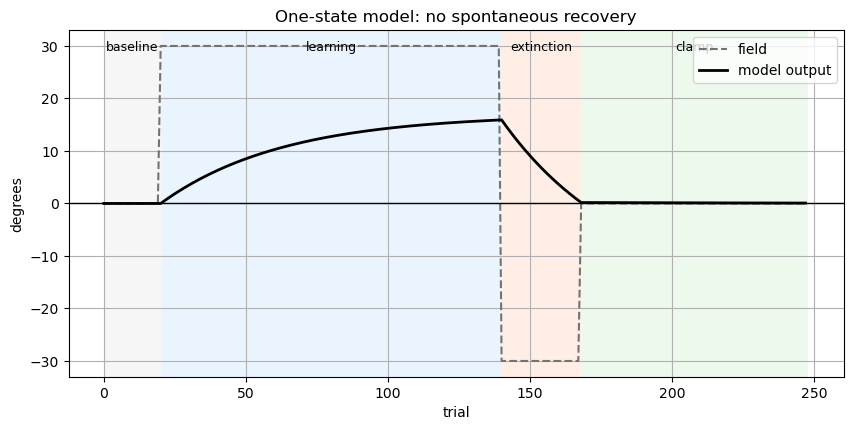

In [5]:
single_result = simulate_single_state()
plot_single_state(single_result, "One-state model: no spontaneous recovery")

**Questions**

- At the start of the clamp phase, is the one-state output close to baseline?
- During the clamp phase, does the model rebound upward, or does it simply decay?
- Why would a one-state model have trouble producing spontaneous recovery after visible behavior has returned to baseline?

<a id="section4"></a>
## 4. Part B - Two-State Model

Now split the adaptive memory into a fast process and a slow process:

$$ x_f(n+1) = A_f x_f(n) + B_f e(n) $$

$$ x_s(n+1) = A_s x_s(n) + B_s e(n) $$

$$ x(n) = x_f(n) + x_s(n) $$

The fast process has larger error sensitivity, but poorer retention. The slow process has smaller error sensitivity, but better retention.

In [6]:
def two_state_output(x_fast, x_slow):
    # STUDENT CODE HERE
    return x_fast + x_slow


def update_two_state(x_fast, x_slow, e,
                     A_f=A_fast, B_f=B_fast,
                     A_s=A_slow, B_s=B_slow):
    # STUDENT CODE HERE
    x_fast_next = A_f * x_fast + B_f * e
    x_slow_next = A_s * x_slow + B_s * e
    return x_fast_next, x_slow_next


check("two-state output sums states", two_state_output(2.0, 3.0), 5.0)
check("two-state learns from zero", update_two_state(0.0, 0.0, 30.0), (0.9, 0.12))
check("two-state retains and updates", update_two_state(10.0, 5.0, -5.0), (9.05, 4.96))

PASS: two-state output sums states
PASS: two-state learns from zero
PASS: two-state retains and updates


In [7]:
def simulate_two_state(error_noise_sd=0.0, seed=0):
    rng = np.random.default_rng(seed)
    trace = _empty_trace()
    trace["x_fast"] = []
    trace["x_slow"] = []
    phase_starts = {}
    x_fast = 0.0
    x_slow = 0.0

    def normal_trial(phase, field):
        nonlocal x_fast, x_slow
        output = two_state_output(x_fast, x_slow)
        observed = output + rng.normal(0.0, error_noise_sd)
        e = compute_error(field, observed)
        _append(trace, phase, field, output, observed, e)
        trace["x_fast"].append(x_fast)
        trace["x_slow"].append(x_slow)
        x_fast, x_slow = update_two_state(x_fast, x_slow, e)

    def clamp_trial():
        nonlocal x_fast, x_slow
        output = two_state_output(x_fast, x_slow)
        observed = output + rng.normal(0.0, error_noise_sd)
        e = 0.0
        _append(trace, "clamp", 0.0, output, observed, e)
        trace["x_fast"].append(x_fast)
        trace["x_slow"].append(x_slow)
        x_fast, x_slow = update_two_state(x_fast, x_slow, e)

    phase_starts["baseline"] = 0
    for _ in range(baseline_trials):
        normal_trial("baseline", 0.0)

    phase_starts["learning"] = len(trace["trial"])
    for _ in range(learning_trials):
        normal_trial("learning", adaptation_field)

    phase_starts["extinction"] = len(trace["trial"])
    for _ in range(max_extinction_trials):
        normal_trial("extinction", extinction_field)
        if abs(two_state_output(x_fast, x_slow)) <= baseline_tolerance:
            break

    phase_starts["clamp"] = len(trace["trial"])
    for _ in range(clamp_trials):
        clamp_trial()

    return _finalize(trace, phase_starts=phase_starts, final_state=(x_fast, x_slow))


def plot_two_state(result, title="Two-state model"):
    fig, ax = plt.subplots(figsize=(10, 4.8))
    shade_phases(ax, result)
    ax.plot(result["trial"], result["field"], color="0.45", ls="--", label="field")
    ax.plot(result["trial"], result["output"], color="black", lw=2.2, label="total output")
    ax.plot(result["trial"], result["x_fast"], color="#d62728", lw=1.7, label="fast state")
    ax.plot(result["trial"], result["x_slow"], color="#1f77b4", lw=1.7, label="slow state")
    if np.std(result["observed_output"] - result["output"]) > 0:
        ax.plot(result["trial"], result["observed_output"], color="0.55", lw=0.8, alpha=0.65,
                label="noisy observed output")
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("trial")
    ax.set_ylabel("degrees")
    ax.set_title(title)
    ax.legend(loc="upper right", ncol=2)
    plt.show()

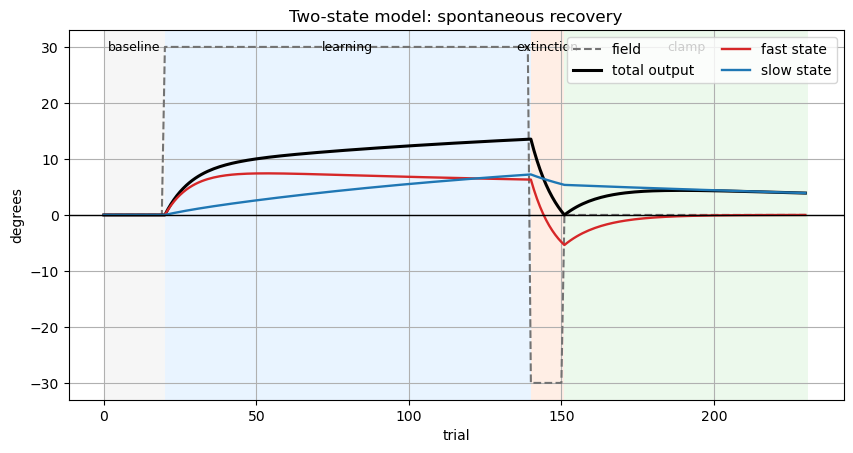

In [8]:
two_result = simulate_two_state()
plot_two_state(two_result, "Two-state model: spontaneous recovery")

**Questions**

- At the start of the clamp phase, what are the signs of the fast and slow states?
- Why can the total output be close to zero even when the hidden states are not close to zero?
- During the clamp phase, why does the total output rebound? Which state is disappearing faster?

<a id="section5"></a>
## 5. Part C - Quantify Spontaneous Recovery

A simple recovery score is the largest increase in output during the clamp:

$$ \text{recovery} = \max(x_{clamp}) - x_{clamp}(0) $$

If the model only decays, this value should be small. If it rebounds, this value should be larger.

In [9]:
def recovery_size(result):
    # STUDENT CODE HERE
    clamp_output = result["output"][result["phase"] == "clamp"]
    return np.max(clamp_output) - clamp_output[0]


fake_result = {
    "phase": np.array(["learning", "clamp", "clamp", "clamp"]),
    "output": np.array([10.0, 0.0, 2.0, 1.0]),
}
check("recovery_size finds rebound during clamp", recovery_size(fake_result), 2.0)

PASS: recovery_size finds rebound during clamp


In [10]:
single_recovery = recovery_size(single_result)
two_recovery = recovery_size(two_result)

print(f"One-state recovery: {single_recovery:.2f} deg")
print(f"Two-state recovery: {two_recovery:.2f} deg")

One-state recovery: 0.00 deg
Two-state recovery: 4.38 deg


<a id="section6"></a>
## 6. Part D - Add Human-Level Noise

So far the simulation has been deterministic. Human movement is noisy, and the error available to the learner is noisy too. Here we add Gaussian trial-to-trial variability to the observed motor output before computing the error:

$$ x_{observed}(n) = x(n) + \eta(n) $$

$$ e(n) = f(n) - x_{observed}(n) $$

During the clamp phase, the error is still forced to zero. The noisy observation is plotted only to show how variable individual reaches might look.

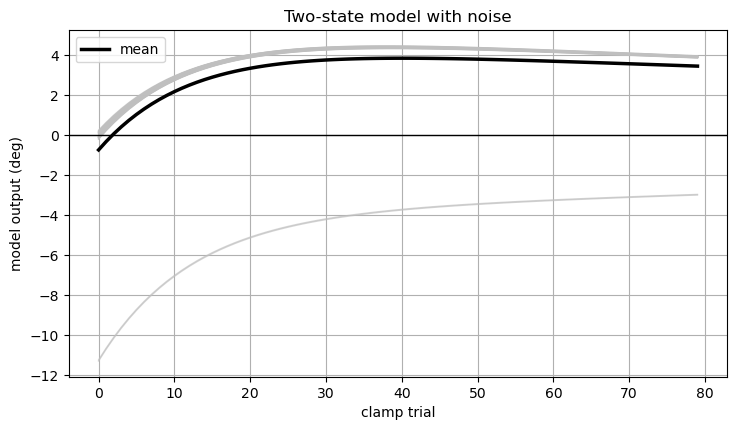

Mean recovery with noise: 4.64 deg
Smallest recovery across runs: 4.19 deg
Largest recovery across runs: 8.30 deg


In [11]:
def clamp_output(result):
    return result["output"][result["phase"] == "clamp"]


def run_noisy_two_state_repetitions(n_runs=30, error_noise_sd=human_noise_sd):
    return [
        simulate_two_state(error_noise_sd=error_noise_sd, seed=seed)
        for seed in range(n_runs)
    ]


def plot_noisy_clamp_recovery(runs, title="Two-state model with noise"):
    clamp_traces = np.array([clamp_output(run) for run in runs])
    mean_trace = clamp_traces.mean(axis=0)
    clamp_trial = np.arange(clamp_traces.shape[1])

    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    for trace in clamp_traces:
        ax.plot(clamp_trial, trace, color="0.75", lw=1, alpha=0.65)
    ax.plot(clamp_trial, mean_trace, color="black", lw=2.5, label="mean")
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("clamp trial")
    ax.set_ylabel("model output (deg)")
    ax.set_title(title)
    ax.legend()
    plt.show()


noisy_runs = run_noisy_two_state_repetitions()
plot_noisy_clamp_recovery(noisy_runs)

noisy_recoveries = np.array([recovery_size(run) for run in noisy_runs])
print(f"Mean recovery with noise: {noisy_recoveries.mean():.2f} deg")
print(f"Smallest recovery across runs: {noisy_recoveries.min():.2f} deg")
print(f"Largest recovery across runs: {noisy_recoveries.max():.2f} deg")

**Questions**

- Is spontaneous recovery still visible in most noisy runs?
- Does noise mainly change the hidden mechanism, or does it change how confidently we can see the mechanism from behavior?
- If you increased `human_noise_sd`, what would happen to the single-run plot? What would happen to the average across many runs?

<a id="section7"></a>
## 7. Discussion

Please edit this cell to answer:

1. Why does the one-state model fail to show spontaneous recovery after extinction?
2. In the two-state model, why are the fast and slow states opposed at the beginning of the clamp?
3. Why does the two-state model rebound during the clamp even though the error is zero?
4. What does adding noise teach you about the difference between a model's mechanism and the data we observe from people?